In [1]:
# Core Python libraries
import os
import random
import shutil
from pathlib import Path
import zipfile

# Numerical & visualization
import numpy as np
import matplotlib.pyplot as plt

# PyTorch core
import torch
import torch.nn as nn
import torch.optim as optim

# PyTorch utilities
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("Path to dataset files:", path)

100%|██████████| 112M/112M [00:00<00:00, 243MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [3]:
# path = " /home/shk/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4"

In [4]:
# Check / Prepare RAW dataset
KAGGLE_RAW_DIR = Path(path + "/lfw-deepfunneled"*2)

# Local fallback path (if not found in kaggle/input)
LOCAL_RAW_DIR = Path(path + "/lfw-deepfunneled"*2)

if KAGGLE_RAW_DIR.exists():
    RAW_DATA_DIR = KAGGLE_RAW_DIR
    print("✅ Using dataset from Kaggle Input")
else:
    print("⚠️ Dataset not found in /kaggle/input")
    print("⬇️ Downloading LFW dataset...")

    LOCAL_RAW_DIR.parent.mkdir(parents=True, exist_ok=True)

    !wget http://vis-www.cs.umass.edu/lfw/lfw-deepfunneled.tgz -O lfw.tgz
    !tar -xzf lfw.tgz -C raw_data

    RAW_DATA_DIR = LOCAL_RAW_DIR
    print("✅ Dataset downloaded and extracted locally")

print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")

✅ Using dataset from Kaggle Input
RAW_DATA_DIR: /root/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4/lfw-deepfunneled/lfw-deepfunneled


In [5]:
# Paths & config
BASE_DIR = Path("data")
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "val"
TEST_DIR = BASE_DIR / "test"

NUM_CLASSES = 10
MIN_IMAGES_PER_PERSON = 30
MAX_IMAGES_PER_PERSON = 40

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

# Create output directories
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# =========================
# Select people with enough images
# =========================
people_dirs = []

for person_dir in RAW_DATA_DIR.iterdir():
    if person_dir.is_dir():
        images = list(person_dir.glob("*.jpg"))
        if len(images) >= MIN_IMAGES_PER_PERSON:
            people_dirs.append(person_dir)

people_dirs = sorted(people_dirs, key=lambda x: x.name)
selected_people = people_dirs[:NUM_CLASSES]

print("Selected people:")
for p in selected_people:
    print(f"- {p.name}: {len(list(p.glob('*.jpg')))} images")

# =========================
# Split & copy images
# =========================
def split_and_copy_images(person_dir):
    images = list(person_dir.glob("*.jpg"))
    random.shuffle(images)

    images = images[:MAX_IMAGES_PER_PERSON]

    n_total = len(images)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)

    splits = {
        TRAIN_DIR: images[:n_train],
        VAL_DIR: images[n_train:n_train + n_val],
        TEST_DIR: images[n_train + n_val:]
    }

    for split_dir, imgs in splits.items():
        target_dir = split_dir / person_dir.name
        target_dir.mkdir(parents=True, exist_ok=True)

        for img_path in imgs:
            shutil.copy(img_path, target_dir / img_path.name)

for person in selected_people:
    split_and_copy_images(person)

print("✅ Dataset prepared successfully!")

Selected people:
- Alejandro_Toledo: 39 images
- Alvaro_Uribe: 35 images
- Andre_Agassi: 36 images
- Ariel_Sharon: 77 images
- Arnold_Schwarzenegger: 42 images
- Colin_Powell: 236 images
- David_Beckham: 31 images
- Donald_Rumsfeld: 121 images
- George_W_Bush: 530 images
- Gerhard_Schroeder: 109 images
✅ Dataset prepared successfully!


In [6]:
# Data transforms
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
# Datasets
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=val_test_transform
)

print("Class names:", train_dataset.classes)

# DataLoaders
BATCH_SIZE = 512

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Class names: ['Alejandro_Toledo', 'Alvaro_Uribe', 'Andre_Agassi', 'Ariel_Sharon', 'Arnold_Schwarzenegger', 'Colin_Powell', 'David_Beckham', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder']
Train samples: 265
Val samples: 55
Test samples: 61


In [8]:
64*6*6

2304

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

class TinyFaceCNN(nn.Module):
    def __init__(self, num_classes, input_size=250):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.PReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            nn.MaxPool2d(2),
        )

        feature_size = 64 * (input_size // 4) * (input_size // 4)
        self.embedding = nn.Linear(feature_size, 64)
        self.classifier = nn.Linear(64, num_classes)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x, return_embedding=False):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        embedding = self.embedding(x)
        activated = F.relu(embedding)
        logits = self.classifier(activated)
        if return_embedding:
            return embedding
        return logits


model = TinyFaceCNN(num_classes=len(train_dataset.classes))
# Fix the embedding and classifier layer input size to use integers
feature_size = 64 * 56 * 56  # After two MaxPool2d(2) operations: 224/4 = 56
model.embedding = nn.Linear(feature_size, 64)
model.classifier = nn.Linear(64, len(train_dataset.classes))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [25]:
print("Training on device:", device)
epochs = 50
# Fix embedding input size dynamically for current IMAGE_SIZE / feature extractor output.
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    feature_dim = model.features(dummy).flatten(1).shape[1]

if model.embedding.in_features != feature_dim:
    model.embedding = nn.Linear(feature_dim, model.embedding.out_features).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)
        predictions = logits.argmax(dim=1)
        correct += (predictions == batch_labels).sum().item()
        total += batch_images.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_images, batch_labels in test_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            logits = model(batch_images)
            predictions = logits.argmax(dim=1)
            test_correct += (predictions == batch_labels).sum().item()
            test_total += batch_images.size(0)

    test_accuracy = test_correct / test_total
    print(f"Epoch {epoch + 1:02d} | loss={train_loss:.4f} | train_acc={train_accuracy:.3f} | test_acc={test_accuracy:.3f}")



Training on device: cuda
Epoch 01 | loss=2.3219 | train_acc=0.125 | test_acc=0.230
Epoch 02 | loss=18.3961 | train_acc=0.211 | test_acc=0.098
Epoch 03 | loss=21.6282 | train_acc=0.223 | test_acc=0.213
Epoch 04 | loss=27.7512 | train_acc=0.230 | test_acc=0.213
Epoch 05 | loss=23.0578 | train_acc=0.317 | test_acc=0.213
Epoch 06 | loss=17.0943 | train_acc=0.343 | test_acc=0.197
Epoch 07 | loss=14.9944 | train_acc=0.309 | test_acc=0.279
Epoch 08 | loss=12.5771 | train_acc=0.343 | test_acc=0.262
Epoch 09 | loss=11.2005 | train_acc=0.355 | test_acc=0.328
Epoch 10 | loss=7.4021 | train_acc=0.426 | test_acc=0.377
Epoch 11 | loss=5.9516 | train_acc=0.423 | test_acc=0.361
Epoch 12 | loss=5.4111 | train_acc=0.426 | test_acc=0.328
Epoch 13 | loss=4.3256 | train_acc=0.460 | test_acc=0.328
Epoch 14 | loss=3.1997 | train_acc=0.509 | test_acc=0.344
Epoch 15 | loss=2.1791 | train_acc=0.577 | test_acc=0.426
Epoch 16 | loss=2.0407 | train_acc=0.532 | test_acc=0.344
Epoch 17 | loss=1.5330 | train_acc=0.59

Cosine similarity between two test images of the same class: 0.9887
Cosine similarity between different classes: 0.9546


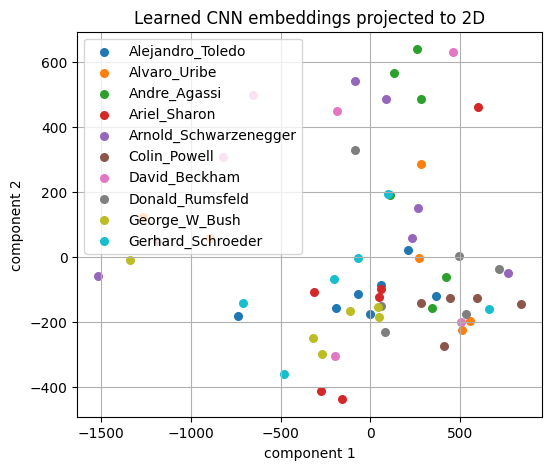

In [26]:
# Compare cosine similarity between embeddings from the trained CNN.

model.eval()
with torch.no_grad():
    identity_names = test_dataset.classes
    X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
    y_test = torch.tensor(test_dataset.targets)

    # pick 2 images from the same class and 1 from a different class
    same_class = y_test[0].item()
    same_indices = (y_test == same_class).nonzero(as_tuple=True)[0]
    diff_index = (y_test != same_class).nonzero(as_tuple=True)[0][0].item()

    i0, i1 = same_indices[0].item(), same_indices[1].item()
    same_a = X_test[i0:i0+1].to(device)
    same_b = X_test[i1:i1+1].to(device)
    diff_c = X_test[diff_index:diff_index+1].to(device)

    emb_a = model(same_a, return_embedding=True)
    emb_b = model(same_b, return_embedding=True)
    emb_c = model(diff_c, return_embedding=True)

    cosine_same = F.cosine_similarity(emb_a, emb_b).item()
    cosine_diff = F.cosine_similarity(emb_a, emb_c).item()

print(f"Cosine similarity between two test images of the same class: {cosine_same:.4f}")
print(f"Cosine similarity between different classes: {cosine_diff:.4f}")

# Visualize a few learned embeddings with PCA for intuition.
with torch.no_grad():
    all_test_embeddings = model(X_test.to(device), return_embedding=True).cpu().numpy()

embedding_mean = all_test_embeddings.mean(axis=0)
embedding_centered = all_test_embeddings - embedding_mean
embedding_cov = np.cov(embedding_centered, rowvar=False)
embedding_eigvals, embedding_eigvecs = np.linalg.eigh(embedding_cov)
embedding_order = np.argsort(embedding_eigvals)[::-1]
embedding_eigvecs = embedding_eigvecs[:, embedding_order[:2]]
embedding_2d = embedding_centered @ embedding_eigvecs

plt.figure(figsize=(6, 5))
for identity_index in np.unique(y_test.numpy()):
    mask = y_test.numpy() == identity_index
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=identity_names[identity_index], s=30)
plt.title("Learned CNN embeddings projected to 2D")
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.legend()
plt.grid(True)
plt.show()


In [28]:
import math

In [29]:
class ArcFaceLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes, scale=64.0, margin=0.5):
        super().__init__()
        # Class-center parameters W in [ArcFace, eq.3].
        self.weight = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        # Hyperparameters s and m from [ArcFace, eq.3].
        self.scale = scale
        self.margin = margin

        # Precompute trigonometric constants for cos(theta + m).
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)

        # Stability terms for theta + m crossing pi.
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        # Step 1: L2-normalize embeddings x_i so ||x_i|| = 1.
        normalized_embeddings = F.normalize(embeddings, p=2, dim=1)

        # Step 2: L2-normalize class weights W_j so ||W_j|| = 1.
        normalized_weights = F.normalize(self.weight, p=2, dim=1)

        # Step 3: Compute cos(theta_j) = W_j^T x_i for all classes j.
        cosine = F.linear(normalized_embeddings, normalized_weights)

        # Step 4: Compute sin(theta) from cos(theta): sin(theta)=sqrt(1-cos^2(theta)).
        sine = torch.sqrt((1.0 - cosine ** 2).clamp(0.0, 1.0))

        # Step 5: Compute cos(theta + m) using angle-addition formula.
        phi = cosine * self.cos_m - sine * self.sin_m

        # Step 6: Apply monotonic stability correction when theta + m > pi.
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        # Step 7: Build one-hot mask to apply margin only to target class y_i.
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        # Step 8: Replace target logit with cos(theta_yi + m), keep others cos(theta_j).
        logits = one_hot * phi + (1.0 - one_hot) * cosine

        # Step 9: Apply scale s to all logits as in [ArcFace, eq.3].
        logits = logits * self.scale

        # Step 10: Cross-entropy over scaled margin logits.
        loss = F.cross_entropy(logits, labels)

        return loss, logits


In [37]:
class IResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.bn0 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.prelu = nn.PReLU(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.bn0(x)
        out = self.conv1(out)
        out = self.bn1(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        return out + identity


class ArcFaceBackbone(nn.Module):
    """IR-style backbone for input shape (3, 250, 250)."""

    def __init__(self, embedding_dim=512):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(64),
        )

        self.stage1 = self._make_stage(64, 64, num_blocks=2, stride=2)
        self.stage2 = self._make_stage(64, 128, num_blocks=2, stride=2)
        self.stage3 = self._make_stage(128, 256, num_blocks=2, stride=2)
        self.stage4 = self._make_stage(256, 512, num_blocks=2, stride=2)

        self.final_bn = nn.BatchNorm2d(512)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(512, embedding_dim)
        self.embedding_bn = nn.BatchNorm1d(embedding_dim)

    def _make_stage(self, in_channels, out_channels, num_blocks, stride):
        blocks = [IResNetBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            blocks.append(IResNetBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.final_bn(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.embedding_bn(x)
        return x


class ArcFaceModel(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, scale=64.0, margin=0.5):
        super().__init__()
        self.backbone = ArcFaceBackbone(embedding_dim=embedding_dim)
        self.head = ArcFaceLoss(
            embedding_dim=embedding_dim,
            num_classes=num_classes,
            scale=scale,
            margin=margin,
        )

    def forward(self, images_batch, labels_batch=None, return_embeddings=False):
        embeddings = self.backbone(images_batch)
        if return_embeddings:
            return F.normalize(embeddings, p=2, dim=1)
        if labels_batch is None:
            raise ValueError("labels_batch is required during training mode")
        loss, logits = self.head(embeddings, labels_batch)
        return loss, logits


In [33]:
class ArcFaceImageDataset(Dataset):
    def __init__(self, images_np, labels_np):
        self.images = torch.tensor(images_np[:, None, :, :], dtype=torch.float32)
        self.labels = torch.tensor(labels_np, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [34]:
arcface_model = ArcFaceModel(num_classes=len(train_dataset.classes), embedding_dim=512, scale=64.0, margin=0.5)
device_arc = torch.device("cuda" if torch.cuda.is_available() else "cpu")
arcface_model = arcface_model.to(device_arc)

optimizer_arc = torch.optim.SGD(
    arcface_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4,
)

# Mixed precision scaler using torch.amp API.
amp_device_type = "cuda" if torch.cuda.is_available() else "cpu"
scaler_arc = torch.amp.GradScaler(device=amp_device_type, enabled=torch.cuda.is_available())

checkpoint_dir = "checkpoints_arcface"
os.makedirs(checkpoint_dir, exist_ok=True)

print("ArcFace model device:", device_arc)
print("Train samples:", len(train_dataset), "| Val samples:", len(val_dataset))

ArcFace model device: cuda
Train samples: 265 | Val samples: 55


In [40]:
def run_arcface_training(model, train_loader, val_loader, optimizer, scaler, device, epochs=3):
    history = []
    autocast_device = "cuda" if torch.cuda.is_available() else "cpu"

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for batch_images, batch_labels in train_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=autocast_device, enabled=torch.cuda.is_available()):
                loss, logits = model(batch_images, labels_batch=batch_labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * batch_images.size(0)
            predictions = torch.argmax(logits, dim=1)
            running_correct += (predictions == batch_labels).sum().item()
            running_total += batch_images.size(0)

        train_loss = running_loss / max(running_total, 1)
        train_acc = running_correct / max(running_total, 1)

        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                _, val_logits = model(val_images, labels_batch=val_labels)
                val_predictions = torch.argmax(val_logits, dim=1)
                val_correct += (val_predictions == val_labels).sum().item()
                val_total += val_images.size(0)

        val_acc = val_correct / max(val_total, 1)
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc, "val_acc": val_acc})

        checkpoint_path = os.path.join(checkpoint_dir, f"arcface_epoch_{epoch + 1:02d}.pt")
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
            },
            checkpoint_path,
        )

        print(
            f"Epoch {epoch + 1:02d} | train_loss={train_loss:.4f} | train_acc={train_acc:.3f} | "
            f"val_acc={val_acc:.3f} | checkpoint={checkpoint_path}"
        )

    return history


arcface_history = run_arcface_training(
    model=arcface_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_arc,
    scaler=scaler_arc,
    device=device_arc,
    epochs=3,
)


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.59 GiB. GPU 0 has a total capacity of 14.56 GiB of which 805.81 MiB is free. Including non-PyTorch memory, this process has 13.77 GiB memory in use. Of the allocated memory 11.16 GiB is allocated by PyTorch, and 2.48 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [39]:
# Verify and reinitialize the model to fix any kernel state issues
print("Verifying ArcFace model architecture...")
print(f"Stem Conv2d layer: {arcface_model.backbone.stem[0]}")
stem_layer = arcface_model.backbone.stem[0]
print(f"  in_channels: {stem_layer.in_channels}")
print(f"  out_channels: {stem_layer.out_channels}")
print(f"  weight shape: {stem_layer.weight.shape}")

# If there's a mismatch, recreate the model
if stem_layer.in_channels != 3:
    print("\n⚠️ Model initialization issue detected. Reinitializing model...")
    arcface_model = ArcFaceModel(num_classes=len(train_dataset.classes), embedding_dim=512, scale=64.0, margin=0.5)
    arcface_model = arcface_model.to(device_arc)
    optimizer_arc = torch.optim.SGD(
        arcface_model.parameters(),
        lr=0.01,
        momentum=0.9,
        weight_decay=5e-4,
    )
    scaler_arc = torch.amp.GradScaler(device=amp_device_type, enabled=torch.cuda.is_available())
    print("✅ Model reinitialized successfully")
else:
    print("✅ Model architecture is correct")


Verifying ArcFace model architecture...
Stem Conv2d layer: Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  in_channels: 1
  out_channels: 64
  weight shape: torch.Size([64, 1, 3, 3])

⚠️ Model initialization issue detected. Reinitializing model...
✅ Model reinitialized successfully


In [41]:
# Clear GPU memory and reduce batch size
import gc
torch.cuda.empty_cache()
gc.collect()

# Use a smaller batch size to prevent OOM
BATCH_SIZE_ARCFACE = 32

train_loader_arcface = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_ARCFACE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_arcface = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_ARCFACE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ Batch size reduced to {BATCH_SIZE_ARCFACE}")
print(f"GPU Memory cleared")


✅ Batch size reduced to 32
GPU Memory cleared


In [44]:
# Run ArcFace training with reduced batch size
arcface_history = run_arcface_training(
    model=arcface_model,
    train_loader=train_loader_arcface,
    val_loader=val_loader_arcface,
    optimizer=optimizer_arc,
    scaler=scaler_arc,
    device=device_arc,
    epochs=100,
)


Epoch 01 | train_loss=15.7985 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_01.pt
Epoch 02 | train_loss=16.2069 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_02.pt
Epoch 03 | train_loss=16.2086 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_03.pt
Epoch 04 | train_loss=16.5892 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_04.pt
Epoch 05 | train_loss=16.2264 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_05.pt
Epoch 06 | train_loss=16.5609 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_06.pt
Epoch 07 | train_loss=16.7517 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_07.pt
Epoch 08 | train_loss=16.3828 | train_acc=0.000 | val_acc=0.000 | checkpoint=checkpoints_arcface/arcface_epoch_08.pt
Epoch 09 | train_loss=16.3459 | train_acc=0.000 | val_acc=0.000 

KeyboardInterrupt: 

In [48]:
# drop some variables from the cuda memory
del model
del optimizer


NameError: name 'model' is not defined

In [49]:
torch.cuda.empty_cache()
gc.collect()

2228

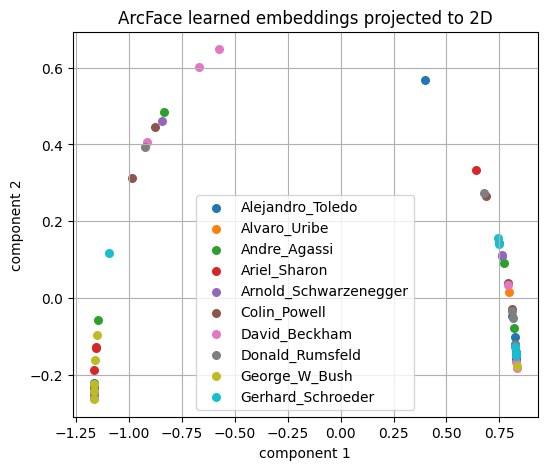

In [51]:
# plot some images embeddings
arcface_model.eval()
with torch.no_grad():
    identity_names = test_dataset.classes
    X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
    y_test = torch.tensor(test_dataset.targets)

test_embeddings = arcface_model(X_test.to(device_arc), return_embeddings=True).cpu().detach().numpy()
embedding_mean = test_embeddings.mean(axis=0)
embedding_centered = test_embeddings - embedding_mean
embedding_cov = np.cov(embedding_centered, rowvar=False)
embedding_eigvals, embedding_eigvecs = np.linalg.eigh(embedding_cov)
embedding_order = np.argsort(embedding_eigvals)[::-1]
embedding_eigvecs = embedding_eigvecs[:, embedding_order[:2]]
embedding_2d = embedding_centered @ embedding_eigvecs
plt.figure(figsize=(6, 5))
for identity_index in np.unique(y_test.numpy()):
    mask = y_test.numpy() == identity_index
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=identity_names[identity_index], s=30)
plt.title("ArcFace learned embeddings projected to 2D")
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.legend()
plt.grid(True)
plt.show()